<a href="https://colab.research.google.com/github/Varsh3689/USLA_ASSIGNMENT/blob/main/24071A6765USLA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import warnings
warnings.filterwarnings('ignore')
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage
from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import cut_tree

In [26]:
import os

# The user has indicated the file should be at '/content/OnlineRetail.csv'
file_path = '/content/OnlineRetail.csv'

if os.path.exists(file_path):
    print(f"File 'OnlineRetail.csv' found at {file_path}.")
else:
    print(f"File 'OnlineRetail.csv' not found at {file_path}. Please ensure it has been uploaded to the /content/ directory.")

File 'OnlineRetail.csv' found at /content/OnlineRetail.csv.


---

### Step 1: Reading and Understanding Data

In [27]:
# Reading the data on which analysis needs to be done
retail = pd.read_csv(file_path, sep=",", encoding="ISO-8859-1", header=0, engine='python', on_bad_lines='skip')
display(retail.head())

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


#### Data Overview

In [28]:
# shape of df
print('Shape of DataFrame:', retail.shape)

# df info
print('\nDataFrame Info:')
retail.info()

# df description
print('\nDataFrame Description:')
display(retail.describe())

Shape of DataFrame: (541909, 8)

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB

DataFrame Description:


,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


---

### Step 2: Data Cleansing

In [29]:
# Calculating the Missing Values % contribution in DF
df_null = round(100*(retail.isnull().sum())/len(retail), 2)
display(df_null)

,0
InvoiceNo,0.00
StockCode,0.00
Description,0.27
Quantity,0.00
InvoiceDate,0.00
UnitPrice,0.00
CustomerID,24.93
Country,0.00


In [30]:
# Dropping rows having missing values
retail = retail.dropna()
print('Shape of DataFrame after dropping nulls:', retail.shape)

Shape of DataFrame after dropping nulls: (406829, 8)


In [31]:
# Changing the datatype of Customer Id as per Business understanding
retail['CustomerID'] = retail['CustomerID'].astype(str)
retail.info()

<class 'pandas.core.frame.DataFrame'>
Index: 406829 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    406829 non-null  object 
 1   StockCode    406829 non-null  object 
 2   Description  406829 non-null  object 
 3   Quantity     406829 non-null  int64  
 4   InvoiceDate  406829 non-null  object 
 5   UnitPrice    406829 non-null  float64
 6   CustomerID   406829 non-null  object 
 7   Country      406829 non-null  object 
dtypes: float64(1), int64(1), object(6)
memory usage: 27.9+ MB


---

### Step 3: Data Preparation (RFM Analysis)

We will analyze customers based on three factors:
-   **R (Recency):** Number of days since last purchase
-   **F (Frequency):** Number of transactions
-   **M (Monetary):** Total amount of transactions (revenue contributed)

In [32]:
# New Attribute : Monetary
# Convert 'Quantity' and 'UnitPrice' to numeric, handling potential errors
retail['Quantity'] = pd.to_numeric(retail['Quantity'], errors='coerce')
retail['UnitPrice'] = pd.to_numeric(retail['UnitPrice'], errors='coerce')

# Drop rows where Quantity or UnitPrice became NaN after conversion
retail.dropna(subset=['Quantity', 'UnitPrice'], inplace=True)

retail['Amount'] = retail['Quantity'] * retail['UnitPrice']
rfm_m = retail.groupby('CustomerID')['Amount'].sum()
rfm_m = rfm_m.reset_index()
display(rfm_m.head())

,CustomerID,Amount
0,12346.0,0.00
1,12347.0,4310.00
2,12348.0,1797.24
3,12349.0,1757.55
4,12350.0,334.40


In [33]:
# New Attribute : Frequency
rfm_f = retail.groupby('CustomerID')['InvoiceNo'].count()
rfm_f = rfm_f.reset_index()
rfm_f.columns = ['CustomerID', 'Frequency']
display(rfm_f.head())

,CustomerID,Frequency
0,12346.0,2
1,12347.0,182
2,12348.0,31
3,12349.0,73
4,12350.0,17


In [34]:
# Merging Monetary and Frequency dataframes
rfm = pd.merge(rfm_m, rfm_f, on='CustomerID', how='inner')
display(rfm.head())

,CustomerID,Amount,Frequency
0,12346.0,0.00,2
1,12347.0,4310.00,182
2,12348.0,1797.24,31
3,12349.0,1757.55,73
4,12350.0,334.40,17


In [35]:
import re

# New Attribute : Recency

# Ensure 'InvoiceDate' column is string type and strip any whitespace for robust parsing.
retail['InvoiceDate'] = retail['InvoiceDate'].astype(str).str.strip()

# Convert 'InvoiceDate' to datetime. Using infer_datetime_format=True for flexibility.
# errors='coerce' will turn unparseable dates into NaT.
# This is a robust attempt to parse various date formats that might exist.
retail['InvoiceDate'] = pd.to_datetime(retail['InvoiceDate'], infer_datetime_format=True, errors='coerce')

# Diagnostic: Check how many values became NaT after conversion
print(f"Number of NaT values after conversion: {retail['InvoiceDate'].isna().sum()} out of {len(retail)}")

# Drop rows where InvoiceDate could not be parsed (NaT values)
retail.dropna(subset=['InvoiceDate'], inplace=True)

# Check if retail DataFrame became empty after dropping NaT values
if retail.empty:
    print("Warning: The 'retail' DataFrame became empty after dropping unparseable InvoiceDates. Recency cannot be calculated.")
else:
    # Compute the maximum date to know the last transaction date
    max_date = max(retail['InvoiceDate'])
    print('Max InvoiceDate:', max_date)

    # Compute the difference between max date and transaction date
    retail['Diff'] = max_date - retail['InvoiceDate']
    display(retail.head())

Number of NaT values after conversion: 0 out of 406829
Max InvoiceDate: 2011-12-09 12:50:00


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Amount,Diff
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,373 days 04:24:00
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,373 days 04:24:00
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,373 days 04:24:00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,373 days 04:24:00
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,373 days 04:24:00


In [36]:
# Compute last transaction date to get the recency of customers
rfm_p = retail.groupby('CustomerID')['Diff'].min()
rfm_p = rfm_p.reset_index()
display(rfm_p.head())

,CustomerID,Diff
0,12346.0,325 days 02:33:00
1,12347.0,1 days 20:58:00
2,12348.0,74 days 23:37:00
3,12349.0,18 days 02:59:00
4,12350.0,309 days 20:49:00


In [37]:
# Extract number of days only
rfm_p['Diff'] = rfm_p['Diff'].dt.days
display(rfm_p.head())

,CustomerID,Diff
0,12346.0,325
1,12347.0,1
2,12348.0,74
3,12349.0,18
4,12350.0,309


In [38]:
# Merge the dataframes to get the final RFM dataframe
rfm = pd.merge(rfm, rfm_p, on='CustomerID', how='inner')
rfm.columns = ['CustomerID', 'Amount', 'Frequency', 'Recency']
display(rfm.head())

,CustomerID,Amount,Frequency,Recency
0,12346.0,0.00,2,325
1,12347.0,4310.00,182,1
2,12348.0,1797.24,31,74
3,12349.0,1757.55,73,18
4,12350.0,334.40,17,309


#### Outlier Treatment

We will treat outliers as they can skew our dataset. There are two main types of outliers: Statistical and Domain-specific.

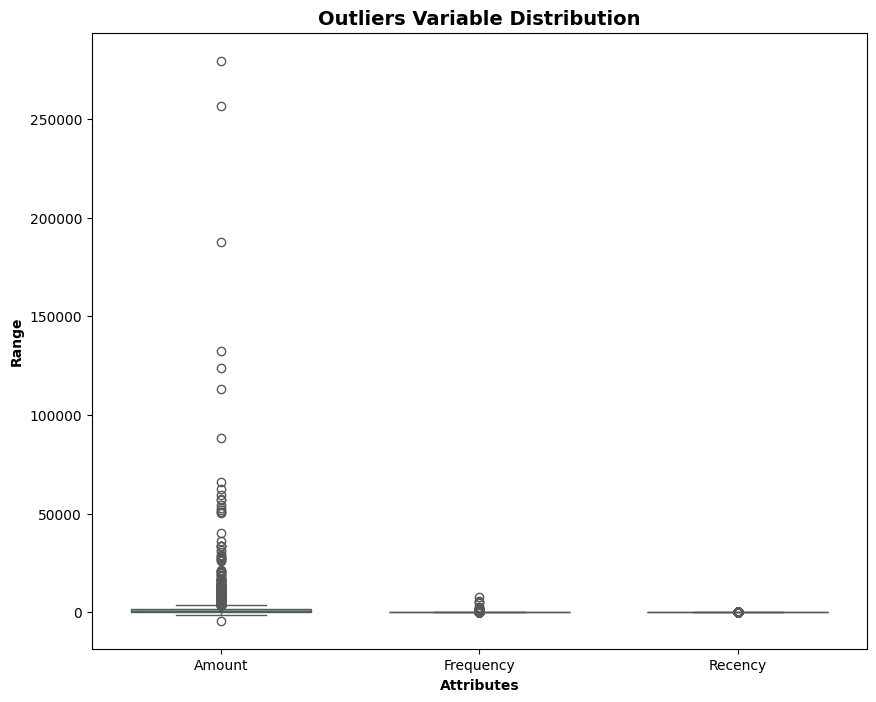

In [39]:
# Outlier Analysis of Amount, Frequency, and Recency

attributes = ['Amount', 'Frequency', 'Recency']
plt.rcParams['figure.figsize'] = [10, 8]

sns.boxplot(data=rfm[attributes], orient="v", palette="Set2", whis=1.5, saturation=1, width=0.7)
plt.title("Outliers Variable Distribution", fontsize=14, fontweight='bold')
plt.ylabel("Range", fontweight='bold')
plt.xlabel("Attributes", fontweight='bold')
plt.show()

In [40]:
# Removing (statistical) outliers for Amount
Q1_amount = rfm.Amount.quantile(0.05)
Q3_amount = rfm.Amount.quantile(0.95)
IQR_amount = Q3_amount - Q1_amount
rfm = rfm[(rfm.Amount >= Q1_amount - 1.5 * IQR_amount) & (rfm.Amount <= Q3_amount + 1.5 * IQR_amount)]

# Removing (statistical) outliers for Recency
Q1_recency = rfm.Recency.quantile(0.05)
Q3_recency = rfm.Recency.quantile(0.95)
IQR_recency = Q3_recency - Q1_recency
rfm = rfm[(rfm.Recency >= Q1_recency - 1.5 * IQR_recency) & (rfm.Recency <= Q3_recency + 1.5 * IQR_recency)]

# Removing (statistical) outliers for Frequency
Q1_frequency = rfm.Frequency.quantile(0.05)
Q3_frequency = rfm.Frequency.quantile(0.95)
IQR_frequency = Q3_frequency - Q1_frequency
rfm = rfm[(rfm.Frequency >= Q1_frequency - 1.5 * IQR_frequency) & (rfm.Frequency <= Q3_frequency + 1.5 * IQR_frequency)]

# Reset index after outlier removal to ensure a clean RangeIndex for subsequent steps
rfm.reset_index(drop=True, inplace=True)

print("Shape of DataFrame after outlier removal:", rfm.shape)

Shape of DataFrame after outlier removal: (4293, 4)


#### Rescaling the Attributes

It is extremely important to rescale the variables so that they have a comparable scale. We will use Standardisation (mean-0, sigma-1).

In [41]:
# Rescaling the attributes
rfm_df = rfm[['Amount', 'Frequency', 'Recency']]

# Instantiate StandardScaler
scaler = StandardScaler()

# fit_transform
rfm_df_scaled = scaler.fit_transform(rfm_df)

print('Shape of scaled DataFrame:', rfm_df_scaled.shape)

# Create a DataFrame with the scaled values and retain the index from rfm_df
rfm_df_scaled = pd.DataFrame(rfm_df_scaled, columns=['Amount', 'Frequency', 'Recency'], index=rfm_df.index)
display(rfm_df_scaled.head())

Shape of scaled DataFrame: (4293, 3)


,Amount,Frequency,Recency
0,-0.723738,-0.752888,2.301611
1,1.731617,1.042467,-0.906466
2,0.300128,-0.463636,-0.183658
3,0.277517,-0.044720,-0.738141
4,-0.533235,-0.603275,2.143188


---

### Step 4: Model Building

#### K-Means Clustering

K-means clustering is a popular unsupervised machine learning algorithm. It works by initializing `k` means, categorizing each item to its closest mean, and updating the mean's coordinates iteratively.

In [42]:
# k-means with some arbitrary k (e.g., k=4)
kmeans = KMeans(n_clusters=4, max_iter=50, random_state=42)
kmeans.fit(rfm_df_scaled)

print('Cluster Labels for k=4:\n', kmeans.labels_[:10])

Cluster Labels for k=4:
 [2 1 0 0 2 0 2 2 2 1]


#### Finding the Optimal Number of Clusters

##### Elbow Curve Method

This method helps determine the optimal number of clusters by plotting the sum of squared distances (SSD) for different numbers of clusters.

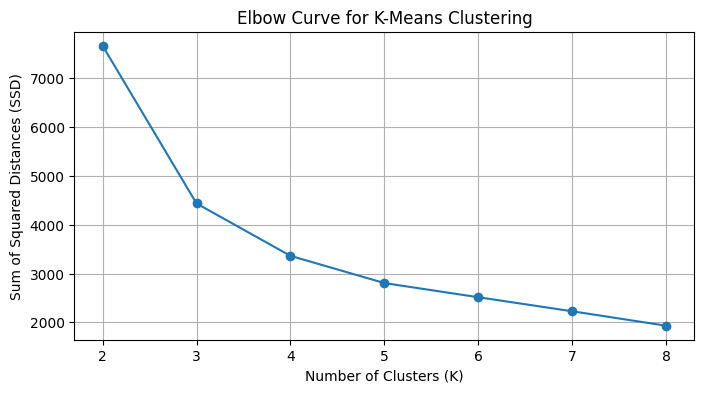

In [43]:
# Elbow-curve/SSD
ssd = []
range_n_clusters = [2, 3, 4, 5, 6, 7, 8]

for num_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=num_clusters, max_iter=50, random_state=42)
    kmeans.fit(rfm_df_scaled)
    ssd.append(kmeans.inertia_)

# plot the SSDs for each n_clusters
plt.figure(figsize=(8, 4))
plt.plot(range_n_clusters, ssd, marker='o')
plt.title('Elbow Curve for K-Means Clustering')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Sum of Squared Distances (SSD)')
plt.grid(True)
plt.show()

##### Silhouette Analysis

The silhouette score measures how similar an object is to its own cluster compared to other clusters. Scores range from -1 to 1, with 1 indicating well-separated clusters.

In [44]:
# Silhouette analysis
range_n_clusters = [2, 3, 4, 5, 6, 7, 8]

for num_clusters in range_n_clusters:
    # Initialize KMeans
    kmeans = KMeans(n_clusters=num_clusters, max_iter=50, random_state=42)
    kmeans.fit(rfm_df_scaled)

    cluster_labels = kmeans.labels_

    # Silhouette score
    silhouette_avg = silhouette_score(rfm_df_scaled, cluster_labels)
    print("For n_clusters={0}, the silhouette score is {1}".format(num_clusters, silhouette_avg))

For n_clusters=2, the silhouette score is 0.539476924749887
For n_clusters=3, the silhouette score is 0.5084896296141937
For n_clusters=4, the silhouette score is 0.48506020563508856
For n_clusters=5, the silhouette score is 0.4616530636875477
For n_clusters=6, the silhouette score is 0.4366869544784324
For n_clusters=7, the silhouette score is 0.40815162142705946
For n_clusters=8, the silhouette score is 0.32270962857767466


Based on both the Elbow Curve and Silhouette Scores, 3 clusters seem like a reasonable choice.

In [45]:
# Final K-Means model with k=3
kmeans = KMeans(n_clusters=3, max_iter=50, random_state=42)
kmeans.fit(rfm_df_scaled)

# Assign the cluster labels to the original RFM dataframe, aligning by index
rfm['Cluster_Id'] = kmeans.labels_
display(rfm.head())

,CustomerID,Amount,Frequency,Recency,Cluster_Id
0,12346.0,0.00,2,325,2
1,12347.0,4310.00,182,1,1
2,12348.0,1797.24,31,74,0
3,12349.0,1757.55,73,18,0
4,12350.0,334.40,17,309,2


#### Visualizing K-Means Clusters

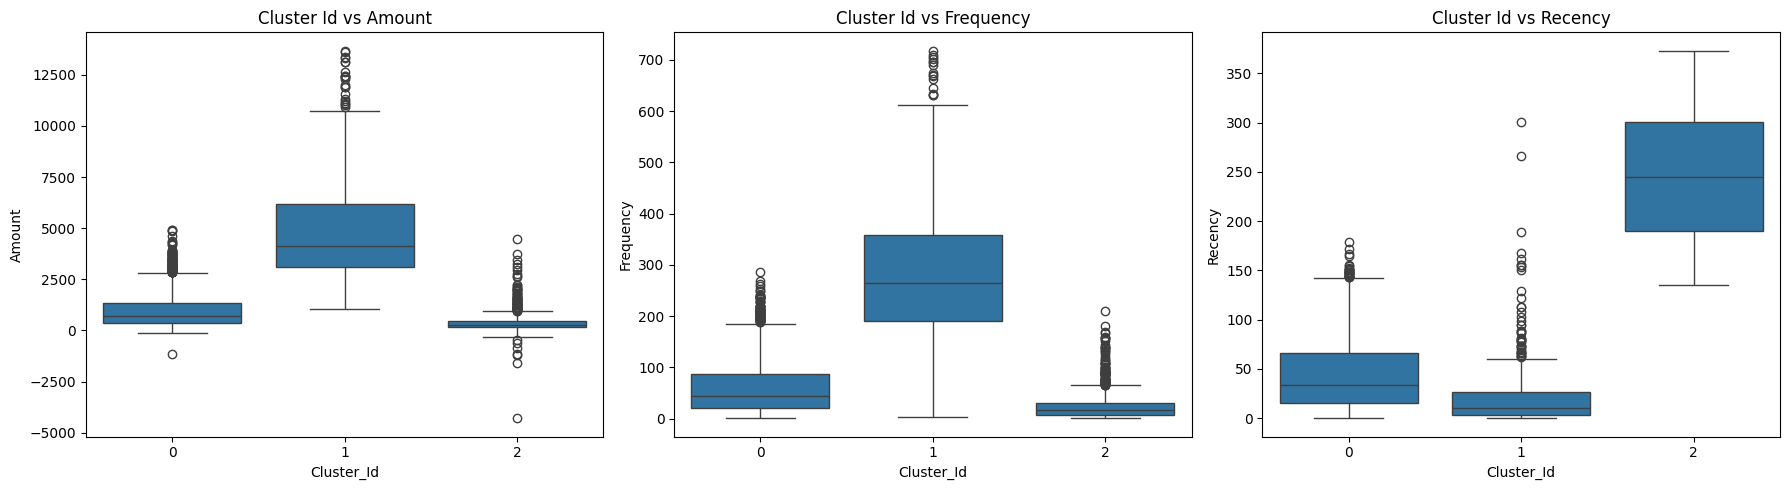

In [46]:
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.boxplot(x='Cluster_Id', y='Amount', data=rfm)
plt.title('Cluster Id vs Amount')

plt.subplot(1, 3, 2)
sns.boxplot(x='Cluster_Id', y='Frequency', data=rfm)
plt.title('Cluster Id vs Frequency')

plt.subplot(1, 3, 3)
sns.boxplot(x='Cluster_Id', y='Recency', data=rfm)
plt.title('Cluster Id vs Recency')

plt.tight_layout()
plt.show()

---

#### Hierarchical Clustering

Hierarchical clustering creates clusters with a predetermined ordering. We'll explore Divisive and Agglomerative types, using different linkage methods.

##### Single Linkage

Distance between two clusters is the shortest distance between any two points in the clusters.

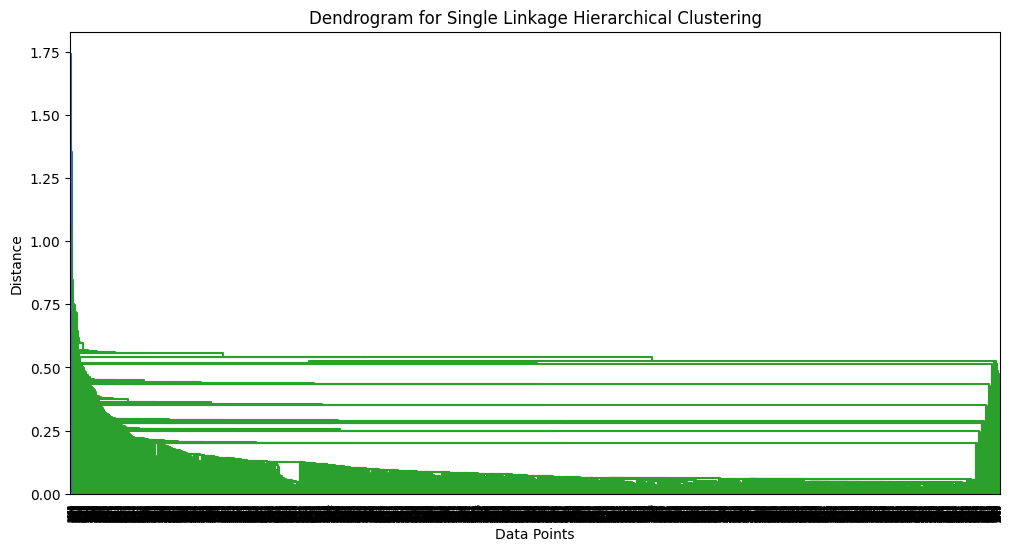

In [47]:
plt.figure(figsize=(12, 6))
mergings_single = linkage(rfm_df_scaled, method="single", metric='euclidean')
dendrogram(mergings_single)
plt.title('Dendrogram for Single Linkage Hierarchical Clustering')
plt.xlabel('Data Points')
plt.ylabel('Distance')
plt.show()

##### Complete Linkage

Distance between two clusters is the longest distance between any two points in the clusters.

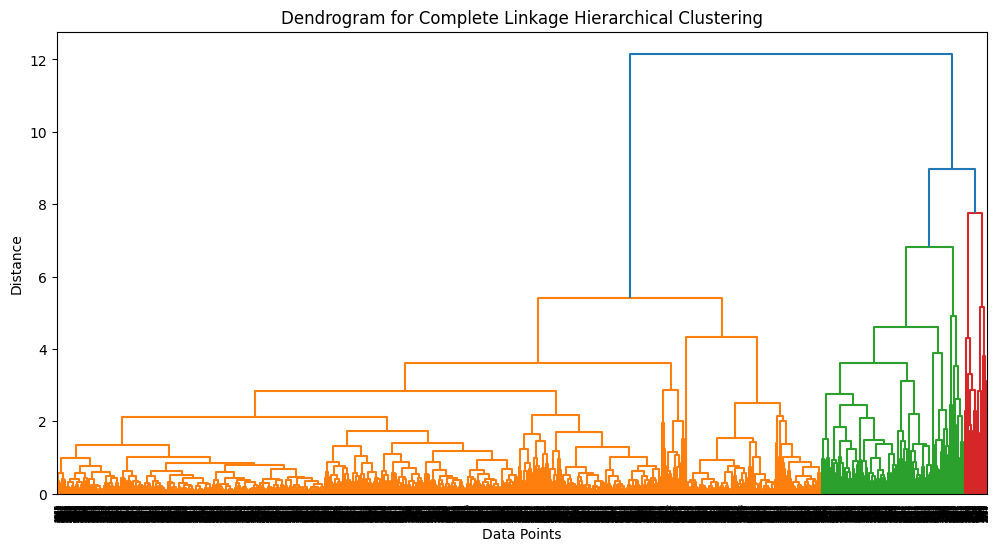

In [48]:
plt.figure(figsize=(12, 6))
mergings_complete = linkage(rfm_df_scaled, method="complete", metric='euclidean')
dendrogram(mergings_complete)
plt.title('Dendrogram for Complete Linkage Hierarchical Clustering')
plt.xlabel('Data Points')
plt.ylabel('Distance')
plt.show()

##### Average Linkage

Distance between two clusters is the average distance between each point in one cluster to every point in the other cluster.

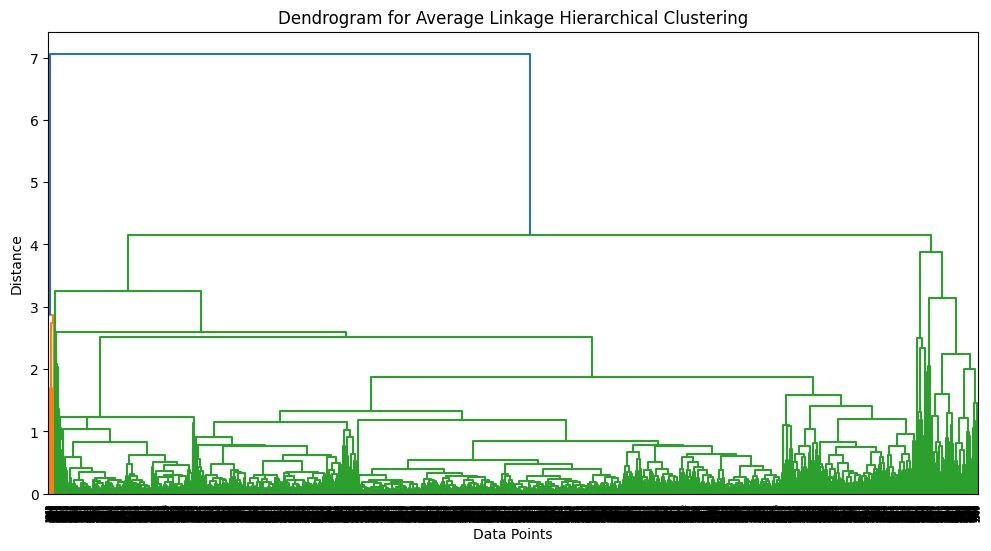

In [49]:
plt.figure(figsize=(12, 6))
mergings_average = linkage(rfm_df_scaled, method="average", metric='euclidean')
dendrogram(mergings_average)
plt.title('Dendrogram for Average Linkage Hierarchical Clustering')
plt.xlabel('Data Points')
plt.ylabel('Distance')
plt.show()

#### Cutting the Dendrogram based on K=3

In [50]:
# 3 clusters from average linkage
cluster_labels_hierarchical = cut_tree(mergings_average, n_clusters=3).reshape(-1, )
print('Hierarchical Cluster Labels (first 10):\n', cluster_labels_hierarchical[:10])

# Assign cluster labels
rfm['Cluster_Labels'] = cluster_labels_hierarchical
display(rfm.head())

Hierarchical Cluster Labels (first 10):
 [0 0 0 0 0 0 0 0 0 0]


,CustomerID,Amount,Frequency,Recency,Cluster_Id,Cluster_Labels
0,12346.0,0.00,2,325,2,0
1,12347.0,4310.00,182,1,1,0
2,12348.0,1797.24,31,74,0,0
3,12349.0,1757.55,73,18,0,0
4,12350.0,334.40,17,309,2,0


#### Visualizing Hierarchical Clusters

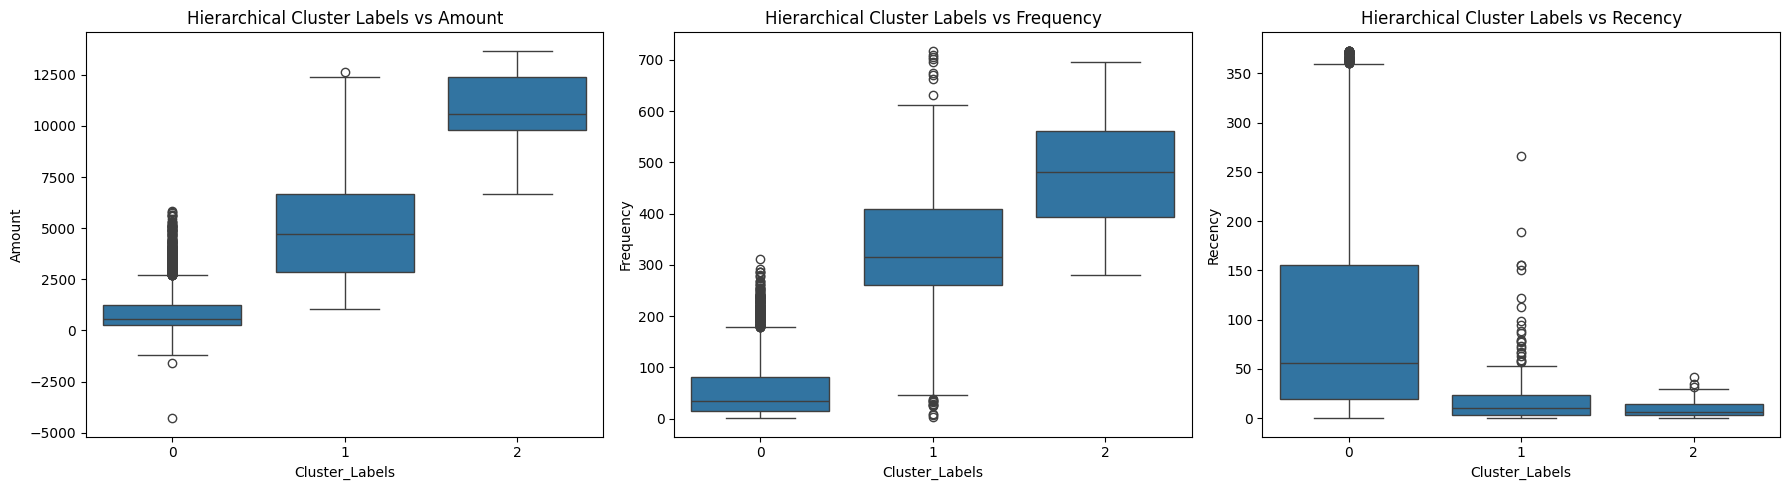

In [51]:
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.boxplot(x='Cluster_Labels', y='Amount', data=rfm)
plt.title('Hierarchical Cluster Labels vs Amount')

plt.subplot(1, 3, 2)
sns.boxplot(x='Cluster_Labels', y='Frequency', data=rfm)
plt.title('Hierarchical Cluster Labels vs Frequency')

plt.subplot(1, 3, 3)
sns.boxplot(x='Cluster_Labels', y='Recency', data=rfm)
plt.title('Hierarchical Cluster Labels vs Recency')

plt.tight_layout()
plt.show()

### Step 5: Final Analysis of Clusters

In [52]:
# K-Means Cluster Analysis
print('K-Means Cluster Analysis:')
km_analysis = rfm.groupby('Cluster_Id')[['Amount', 'Frequency', 'Recency']].mean()
display(km_analysis)

# Hierarchical Cluster Analysis
print('\nHierarchical Cluster Analysis:')
hc_analysis = rfm.groupby('Cluster_Labels')[['Amount', 'Frequency', 'Recency']].mean()
display(hc_analysis)

# You can further interpret these results to define your customer segments.

K-Means Cluster Analysis:


,Amount,Frequency,Recency
Cluster_Id,,,
0,951.730177,59.516141,44.497799
1,4898.735571,286.891784,21.703407
2,388.568259,25.502809,248.295880



Hierarchical Cluster Analysis:


,Amount,Frequency,Recency
Cluster_Labels,,,
0,924.448987,56.577968,98.394115
1,5013.334261,323.197183,20.334507
2,10741.827576,481.666667,9.727273


#### Outlier Treatment

We will treat outliers as they can skew our dataset. There are two main types of outliers: Statistical and Domain-specific.

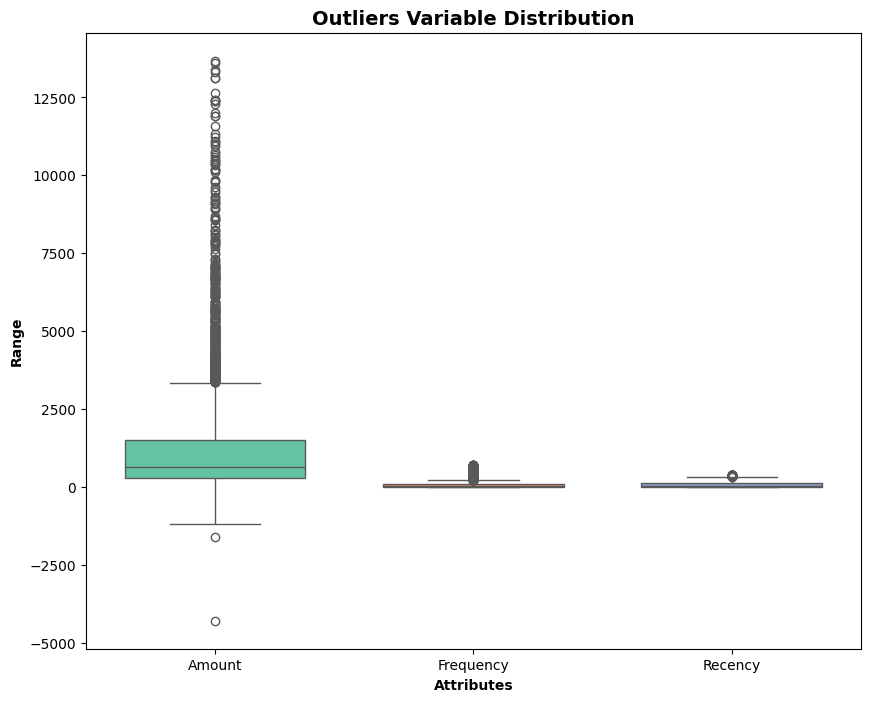

In [55]:
# Outlier Analysis of Amount, Frequency, and Recency

attributes = ['Amount', 'Frequency', 'Recency']
plt.rcParams['figure.figsize'] = [10, 8]

sns.boxplot(data=rfm[attributes], orient="v", palette="Set2", whis=1.5, saturation=1, width=0.7)
plt.title("Outliers Variable Distribution", fontsize=14, fontweight='bold')
plt.ylabel("Range", fontweight='bold')
plt.xlabel("Attributes", fontweight='bold')
plt.show()

In [56]:
# Removing (statistical) outliers for Amount
Q1_amount = rfm.Amount.quantile(0.05)
Q3_amount = rfm.Amount.quantile(0.95)
IQR_amount = Q3_amount - Q1_amount
rfm = rfm[(rfm.Amount >= Q1_amount - 1.5 * IQR_amount) & (rfm.Amount <= Q3_amount + 1.5 * IQR_amount)]

# Removing (statistical) outliers for Recency
Q1_recency = rfm.Recency.quantile(0.05)
Q3_recency = rfm.Recency.quantile(0.95)
IQR_recency = Q3_recency - Q1_recency
rfm = rfm[(rfm.Recency >= Q1_recency - 1.5 * IQR_recency) & (rfm.Recency <= Q3_recency + 1.5 * IQR_recency)]

# Removing (statistical) outliers for Frequency
Q1_frequency = rfm.Frequency.quantile(0.05)
Q3_frequency = rfm.Frequency.quantile(0.95)
IQR_frequency = Q3_frequency - Q1_frequency
rfm = rfm[(rfm.Frequency >= Q1_frequency - 1.5 * IQR_frequency) & (rfm.Frequency <= Q3_frequency + 1.5 * IQR_frequency)]

print("Shape of DataFrame after outlier removal:", rfm.shape)

Shape of DataFrame after outlier removal: (4271, 6)


#### Rescaling the Attributes

It is extremely important to rescale the variables so that they have a comparable scale. We will use Standardisation (mean-0, sigma-1).

In [57]:
# Rescaling the attributes
rfm_df = rfm[['Amount', 'Frequency', 'Recency']]

# Instantiate StandardScaler
scaler = StandardScaler()

# fit_transform
rfm_df_scaled = scaler.fit_transform(rfm_df)

print('Shape of scaled DataFrame:', rfm_df_scaled.shape)

rfm_df_scaled = pd.DataFrame(rfm_df_scaled, columns=['Amount', 'Frequency', 'Recency'])
display(rfm_df_scaled.head())

Shape of scaled DataFrame: (4271, 3)


,Amount,Frequency,Recency
0,-0.759639,-0.771795,2.295613
1,1.916220,1.117217,-0.910045
2,0.356175,-0.467454,-0.187782
3,0.331534,-0.026685,-0.741847
4,-0.552027,-0.614377,2.137309


---

### Step 4: Model Building

#### K-Means Clustering

K-means clustering is a popular unsupervised machine learning algorithm. It works by initializing `k` means, categorizing each item to its closest mean, and updating the mean's coordinates iteratively.

In [58]:
# k-means with some arbitrary k (e.g., k=4)
kmeans = KMeans(n_clusters=4, max_iter=50, random_state=42)
kmeans.fit(rfm_df_scaled)

print('Cluster Labels for k=4:\n', kmeans.labels_[:10])

Cluster Labels for k=4:
 [1 0 3 3 1 3 1 1 1 0]


#### Finding the Optimal Number of Clusters

##### Elbow Curve Method

This method helps determine the optimal number of clusters by plotting the sum of squared distances (SSD) for different numbers of clusters.

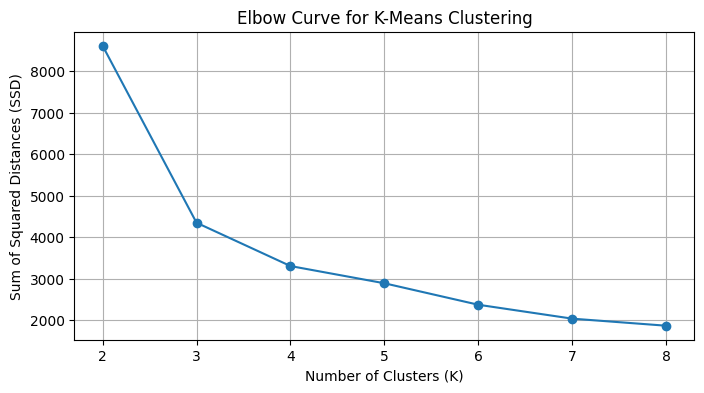

In [59]:
# Elbow-curve/SSD
ssd = []
range_n_clusters = [2, 3, 4, 5, 6, 7, 8]

for num_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=num_clusters, max_iter=50, random_state=42)
    kmeans.fit(rfm_df_scaled)
    ssd.append(kmeans.inertia_)

# plot the SSDs for each n_clusters
plt.figure(figsize=(8, 4))
plt.plot(range_n_clusters, ssd, marker='o')
plt.title('Elbow Curve for K-Means Clustering')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Sum of Squared Distances (SSD)')
plt.grid(True)
plt.show()

##### Silhouette Analysis

The silhouette score measures how similar an object is to its own cluster compared to other clusters. Scores range from -1 to 1, with 1 indicating well-separated clusters.

In [60]:
# Silhouette analysis
range_n_clusters = [2, 3, 4, 5, 6, 7, 8]

for num_clusters in range_n_clusters:
    # Initialize KMeans
    kmeans = KMeans(n_clusters=num_clusters, max_iter=50, random_state=42)
    kmeans.fit(rfm_df_scaled)

    cluster_labels = kmeans.labels_

    # Silhouette score
    silhouette_avg = silhouette_score(rfm_df_scaled, cluster_labels)
    print("For n_clusters={0}, the silhouette score is {1}".format(num_clusters, silhouette_avg))

For n_clusters=2, the silhouette score is 0.3957372527656968
For n_clusters=3, the silhouette score is 0.5022535831650203
For n_clusters=4, the silhouette score is 0.4782571631248905
For n_clusters=5, the silhouette score is 0.40857209425005336
For n_clusters=6, the silhouette score is 0.41452306217902446
For n_clusters=7, the silhouette score is 0.41154049742722143
For n_clusters=8, the silhouette score is 0.37723389933256474


Based on both the Elbow Curve and Silhouette Scores, 3 clusters seem like a reasonable choice.

In [61]:
# Final K-Means model with k=3
kmeans = KMeans(n_clusters=3, max_iter=50, random_state=42)
kmeans.fit(rfm_df_scaled)

# Assign the cluster labels to the original RFM dataframe
rfm['Cluster_Id'] = kmeans.labels_
display(rfm.head())

,CustomerID,Amount,Frequency,Recency,Cluster_Id,Cluster_Labels
0,12346.0,0.00,2,325,1,0
1,12347.0,4310.00,182,1,2,0
2,12348.0,1797.24,31,74,0,0
3,12349.0,1757.55,73,18,0,0
4,12350.0,334.40,17,309,1,0


#### Visualizing K-Means Clusters

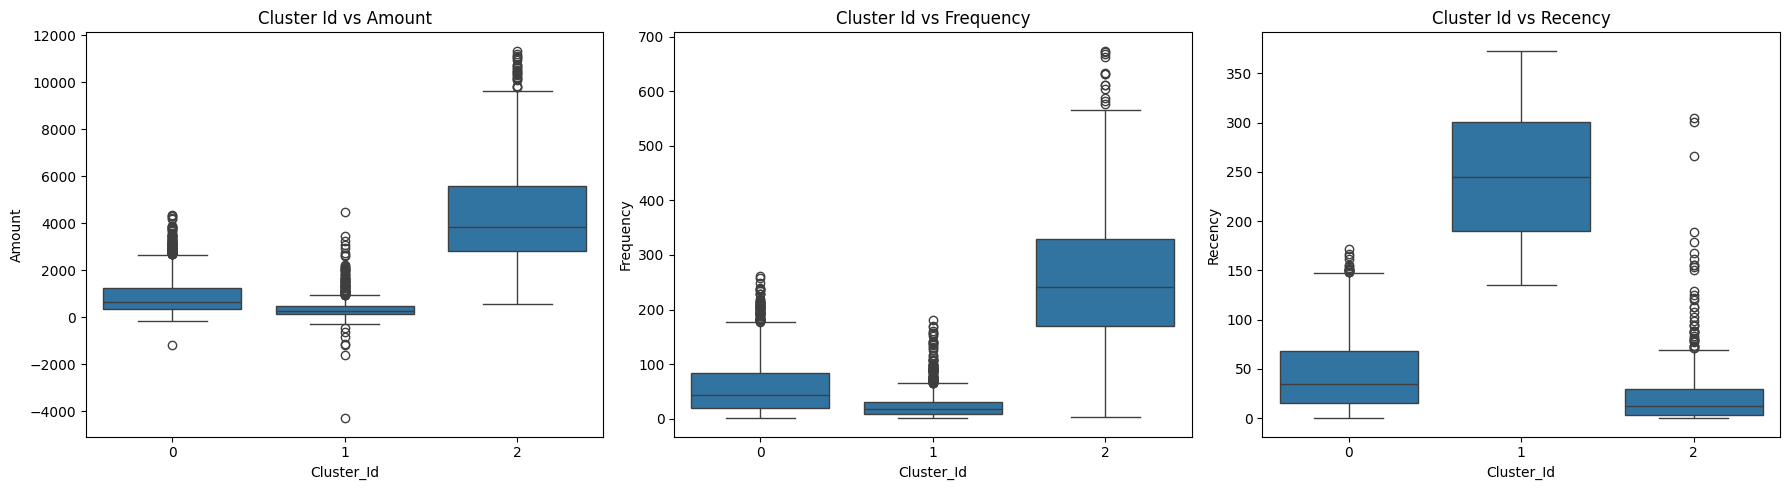

In [62]:
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.boxplot(x='Cluster_Id', y='Amount', data=rfm)
plt.title('Cluster Id vs Amount')

plt.subplot(1, 3, 2)
sns.boxplot(x='Cluster_Id', y='Frequency', data=rfm)
plt.title('Cluster Id vs Frequency')

plt.subplot(1, 3, 3)
sns.boxplot(x='Cluster_Id', y='Recency', data=rfm)
plt.title('Cluster Id vs Recency')

plt.tight_layout()
plt.show()

---

#### Hierarchical Clustering

Hierarchical clustering creates clusters with a predetermined ordering. We'll explore Divisive and Agglomerative types, using different linkage methods.

##### Single Linkage

Distance between two clusters is the shortest distance between any two points in the clusters.

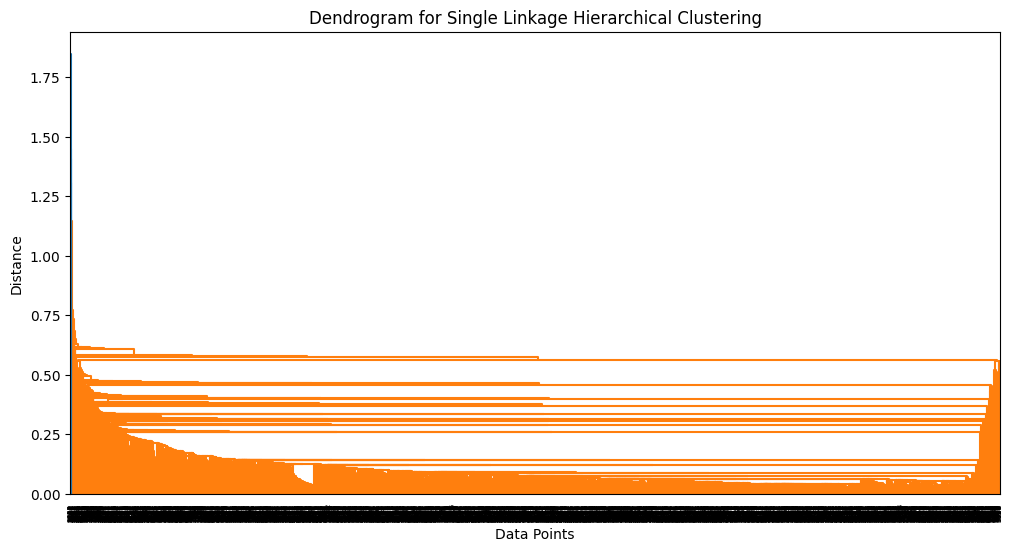

In [63]:
plt.figure(figsize=(12, 6))
mergings_single = linkage(rfm_df_scaled, method="single", metric='euclidean')
dendrogram(mergings_single)
plt.title('Dendrogram for Single Linkage Hierarchical Clustering')
plt.xlabel('Data Points')
plt.ylabel('Distance')
plt.show()

##### Complete Linkage

Distance between two clusters is the longest distance between any two points in the clusters.

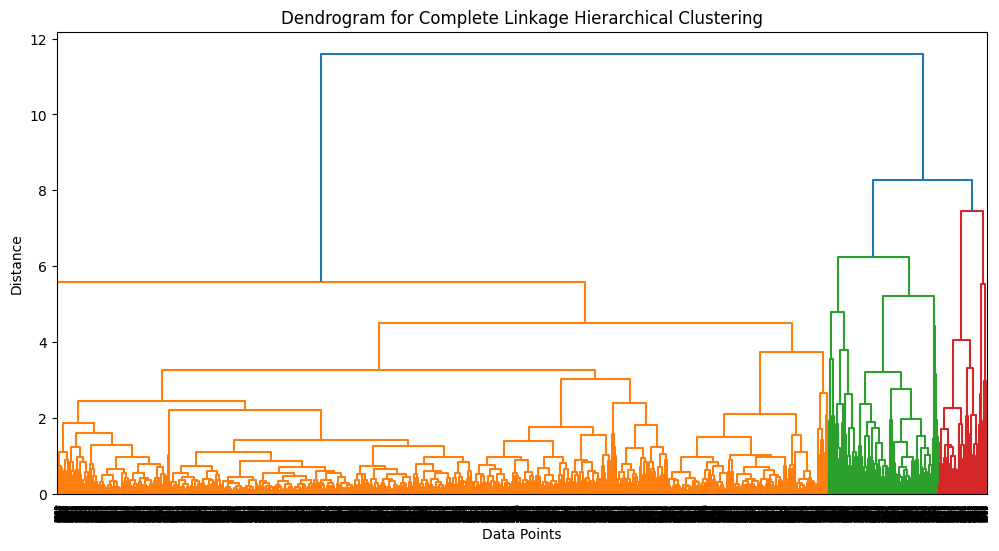

In [64]:
plt.figure(figsize=(12, 6))
mergings_complete = linkage(rfm_df_scaled, method="complete", metric='euclidean')
dendrogram(mergings_complete)
plt.title('Dendrogram for Complete Linkage Hierarchical Clustering')
plt.xlabel('Data Points')
plt.ylabel('Distance')
plt.show()

##### Average Linkage

Distance between two clusters is the average distance between each point in one cluster to every point in the other cluster.

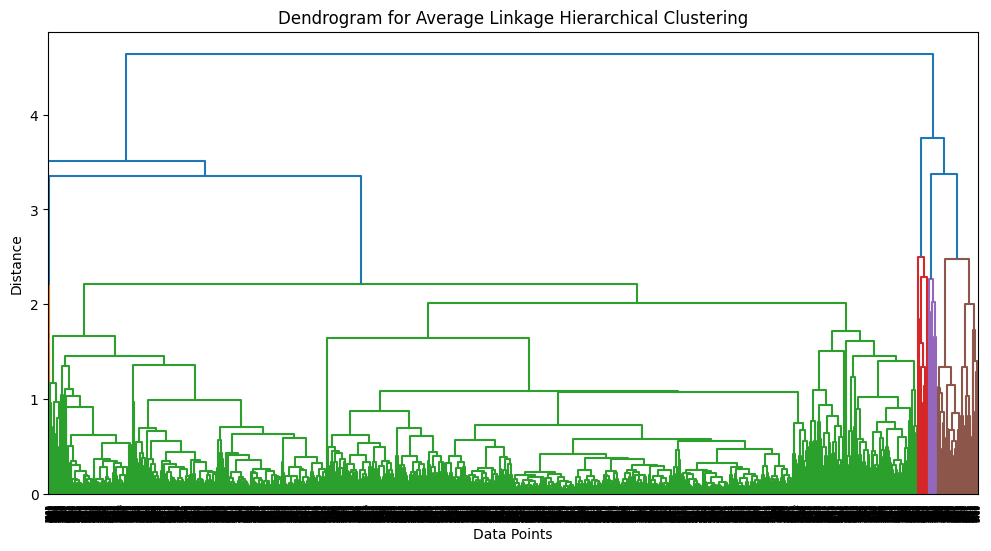

In [65]:
plt.figure(figsize=(12, 6))
mergings_average = linkage(rfm_df_scaled, method="average", metric='euclidean')
dendrogram(mergings_average)
plt.title('Dendrogram for Average Linkage Hierarchical Clustering')
plt.xlabel('Data Points')
plt.ylabel('Distance')
plt.show()

#### Cutting the Dendrogram based on K=3

In [66]:
# 3 clusters from average linkage
cluster_labels_hierarchical = cut_tree(mergings_average, n_clusters=3).reshape(-1, )
print('Hierarchical Cluster Labels (first 10):\n', cluster_labels_hierarchical[:10])

# Assign cluster labels
rfm['Cluster_Labels'] = cluster_labels_hierarchical
display(rfm.head())

Hierarchical Cluster Labels (first 10):
 [0 0 0 0 0 0 0 0 0 0]


,CustomerID,Amount,Frequency,Recency,Cluster_Id,Cluster_Labels
0,12346.0,0.00,2,325,1,0
1,12347.0,4310.00,182,1,2,0
2,12348.0,1797.24,31,74,0,0
3,12349.0,1757.55,73,18,0,0
4,12350.0,334.40,17,309,1,0


#### Visualizing Hierarchical Clusters

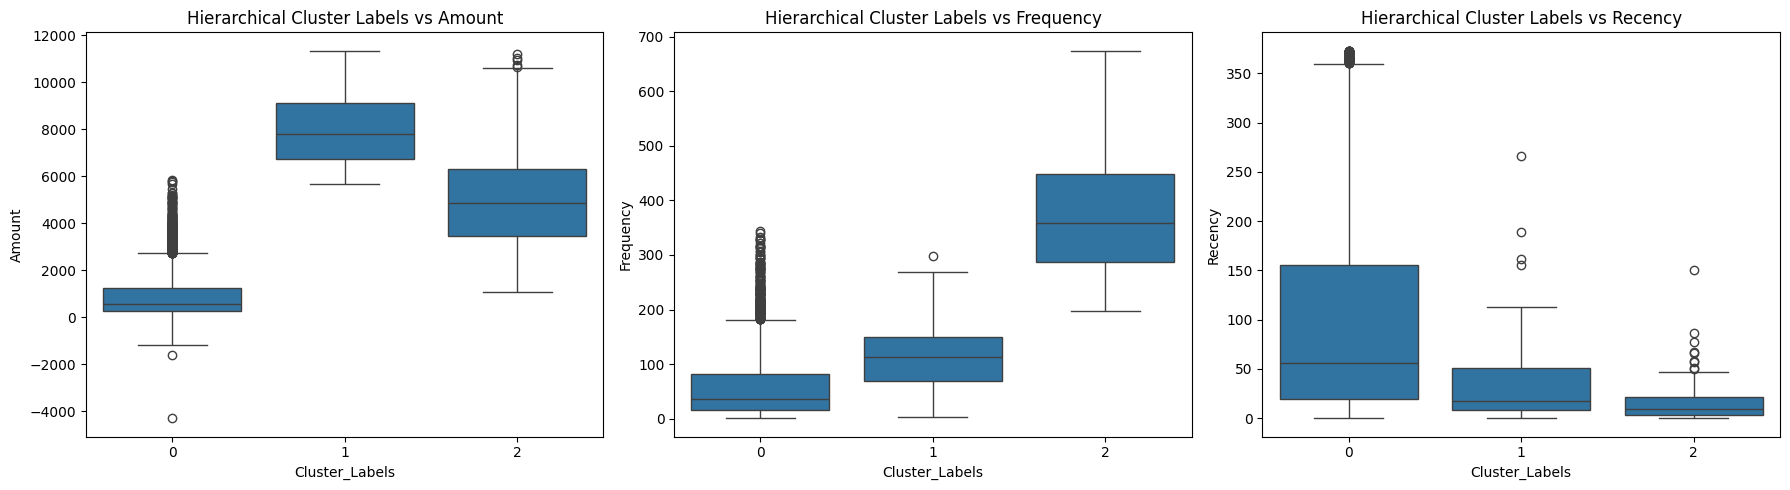

In [67]:
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.boxplot(x='Cluster_Labels', y='Amount', data=rfm)
plt.title('Hierarchical Cluster Labels vs Amount')

plt.subplot(1, 3, 2)
sns.boxplot(x='Cluster_Labels', y='Frequency', data=rfm)
plt.title('Hierarchical Cluster Labels vs Frequency')

plt.subplot(1, 3, 3)
sns.boxplot(x='Cluster_Labels', y='Recency', data=rfm)
plt.title('Hierarchical Cluster Labels vs Recency')

plt.tight_layout()
plt.show()

---

In [68]:
import os

file_size = os.path.getsize(file_path)
print(f"File '{file_path}' size: {file_size} bytes")

# Display the first few lines of the file to inspect its content
print(f"\nFirst 10 lines of '{file_path}':")
!head -n 10 {file_path}

File '/content/OnlineRetail.csv' size: 45580638 bytes

First 10 lines of '/content/OnlineRetail.csv':
InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850,United Kingdom
536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850,United Kingdom
536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850,United Kingdom
536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850,United Kingdom
536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850,United Kingdom
536365,22752,SET 7 BABUSHKA NESTING BOXES,2,12/1/2010 8:26,7.65,17850,United Kingdom
536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,12/1/2010 8:26,4.25,17850,United Kingdom
536366,22633,HAND WARMER UNION JACK,6,12/1/2010 8:28,1.85,17850,United Kingdom
536366,22632,HAND WARMER RED POLKA DOT,6,12/1/2010 8:28,1.85,17850,United Kingdom
